In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
class CustomLinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, x, y):
        # Ensure inputs are standard 1D NumPy arrays for mathematical operations
        x = np.array(x).flatten()
        y = np.array(y).flatten()
        
        # 1. Calculate the mean (average) of x and y
        x_mean, y_mean = np.mean(x), np.mean(y)
        
        # 2. Calculate the terms for the OLS formula
        deviation_x = x - x_mean
        deviation_y = y - y_mean
        
        # 3. Calculate Slope (m) and Intercept (b)
        numerator = np.sum(deviation_x * deviation_y)
        denominator = np.sum(deviation_x ** 2)
        
        self.slope = numerator / denominator
        self.intercept = y_mean - (self.slope * x_mean)


        # self.slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
        # self.intercept = y_mean - (self.slope * x_mean)

    def predict(self, x):
        # Apply the line equation y = mx + b
        x = np.array(x)
        return (self.slope * x) + self.intercept

    def score(self, x, y):
        # Calculate R-squared (R²) accuracy score from scratch
        x = np.array(x).flatten()
        y = np.array(y).flatten()
        
        y_pred = self.predict(x)
        y_mean = np.mean(y)
        
        # Sum of Squared Residuals (errors from our line)
        ss_res = np.sum((y - y_pred) ** 2)
        # Total Sum of Squares (errors from just guessing the mean)
        ss_tot = np.sum((y - y_mean) ** 2)
        
        # R² Formula
        return 1 - (ss_res / ss_tot)

# ==========================================
# TESTING WITH OUR DATA
# ==========================================

x = [15, 21, 33, 20, 7, 17, 24, 11, 40]
y = [77, 89, 96, 87, 96, 80, 91, 66, 99]

# Instantiate and train our custom model
mymodel = CustomLinearRegression()
mymodel.fit(x, y)

# Print the internal parameters discovered by mathematics
print(f"Calculated Slope (m): {mymodel.slope:.2f}")
print(f"Calculated Intercept (b): {mymodel.intercept:.2f}")
print(f"The regression line equasion is y = {mymodel.slope:.2f} X + {mymodel.intercept:.2f}" )

# Make a single prediction
val = 55
pred = mymodel.predict(val)
print(f"Prediction for X={val}: {pred:.2f}")

# Check the R² accuracy score
r2_accuracy = mymodel.score(x, y)
print(f"Model R^2 Accuracy: {r2_accuracy:.2f}")

Calculated Slope (m): 0.60
Calculated Intercept (b): 74.19
The regression line equasion is y = 0.60 X + 74.19
Prediction for X=55: 107.33
Model R^2 Accuracy: 0.34


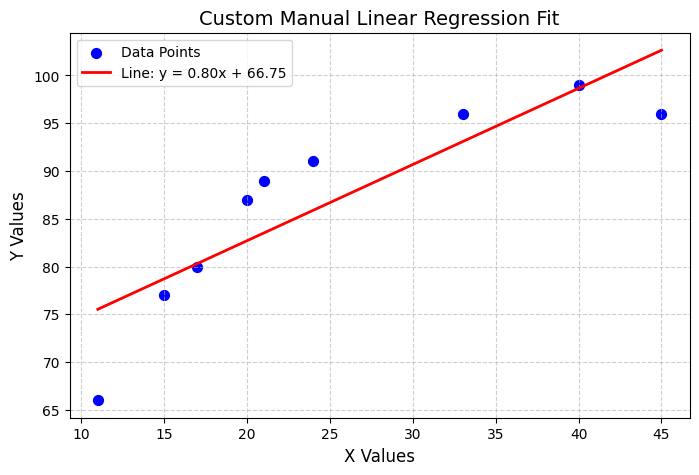

In [13]:
# 4. Generate points for the custom regression line
# We create a smooth range of 100 points from min X to max X
x_line = np.linspace(min(x), max(x), 100)
y_line = mymodel.predict(x_line)

# 5. Create the plot
plt.figure(figsize=(8, 5))

# Plot the raw data points
plt.scatter(x, y, color='blue', label='Data Points', s=50)

# Plot the custom regression line using our calculated formula
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Line: y = {mymodel.slope:.2f}x + {mymodel.intercept:.2f}')

# Customizing the chart layout
plt.title('Custom Manual Linear Regression Fit', fontsize=14)
plt.xlabel('X Values', fontsize=12)
plt.ylabel('Y Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the final plot
plt.show()

Please note that the x-value 7 is an outlier point that significantly affects the accuracy of the regression line. Try changing it to 37 and observe how the accuracy dramatically improves.